In [3]:
# Step 1: Import libraries & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ── Basic Info ──
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check data types and missing values
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Variable Distribution ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [5]:
# Basic statistics for numeric columns
print("=== Statistical Summary ===")
df.describe()

=== Statistical Summary ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# TotalCharges is stored as string — convert to numeric
# spaces " " will become NaN automatically
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN appeared
print("Missing in TotalCharges after fix:", df['TotalCharges'].isnull().sum())

# Drop those rows (only 11 rows — safe to drop)
df.dropna(subset=['TotalCharges'], inplace=True)

print("New shape:", df.shape)  # Should be (7032, 21)

Missing in TotalCharges after fix: 11
New shape: (7032, 21)


In [7]:
# customerID is useless for ML — drop it
df.drop(columns=['customerID'], inplace=True)

# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts:")
print(df['Churn'].value_counts())

print("\nShape after cleaning:", df.shape)  # Should be (7032, 20)

Churn value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64

Shape after cleaning: (7032, 20)


In [8]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (object dtype)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Apply Label Encoding to each
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nAll dtypes after encoding:")
print(df.dtypes)
print("\nSample data:")
df.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

All dtypes after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Sample data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [9]:
print("=== Final Check ===")
print("Shape:", df.shape)
print("\nAny nulls left?", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes)
print("\nChurn distribution:")
print(df['Churn'].value_counts())

=== Final Check ===
Shape: (7032, 20)

Any nulls left? 0

Data types:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


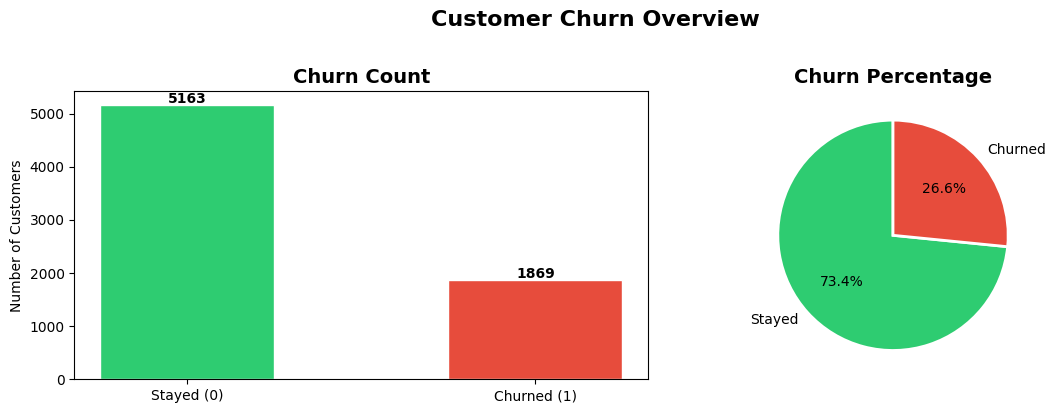

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Stayed (0)', 'Churned (1)'],
            df['Churn'].value_counts().values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(df['Churn'].value_counts().values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(df['Churn'].value_counts().values,
            labels=['Stayed', 'Churned'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

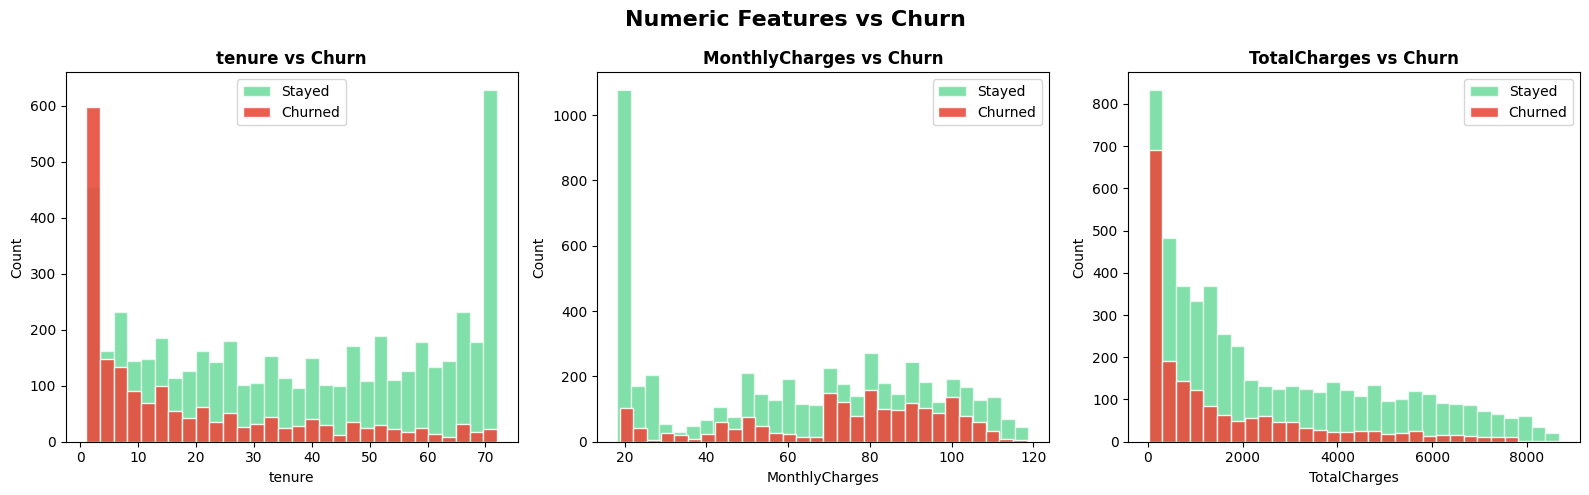

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes,
                           ['tenure', 'MonthlyCharges', 'TotalCharges'],
                           ['#3498db', '#e67e22', '#9b59b6']):
    for churn_val, label, alpha in [(0, 'Stayed', 0.6), (1, 'Churned', 0.9)]:
        ax.hist(df[df['Churn'] == churn_val][col],
                bins=30, alpha=alpha, label=label,
                color='#2ecc71' if churn_val == 0 else '#e74c3c',
                edgecolor='white')
    ax.set_title(f'{col} vs Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Numeric Features vs Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

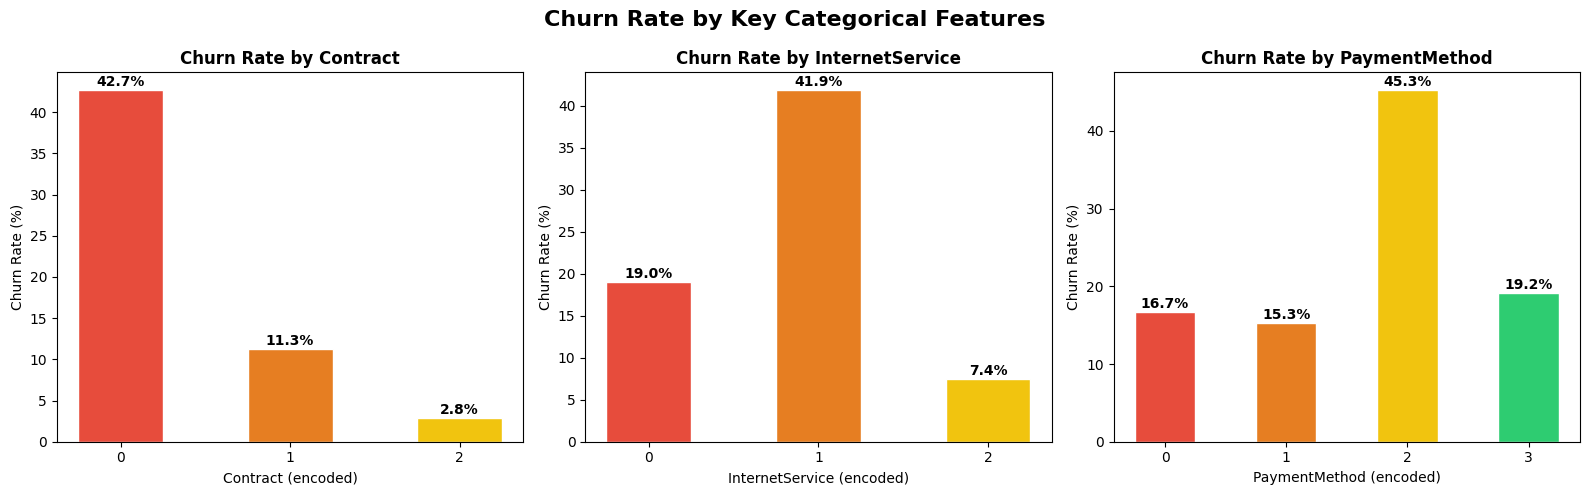

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_features = ['Contract', 'InternetService', 'PaymentMethod']

for ax, col in zip(axes, cat_features):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'][:len(churn_rate)],
                  edgecolor='white', width=0.5)
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_xlabel(col + ' (encoded)')
    ax.set_ylabel('Churn Rate (%)')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

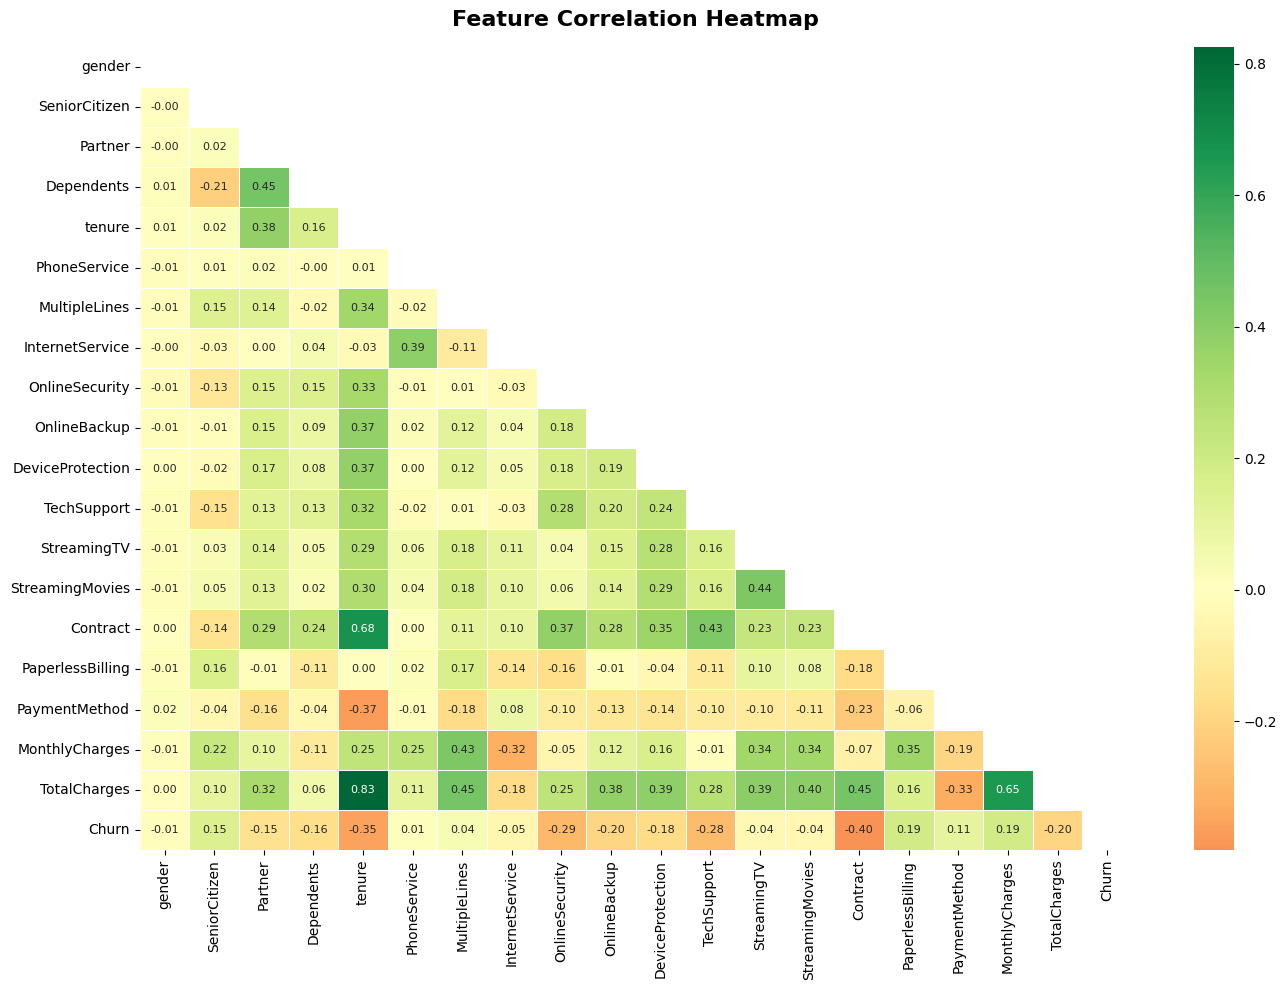

In [13]:
plt.figure(figsize=(14, 10))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7032, 19)
Target shape: (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [15]:
# 80% train, 20% test — random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTrain Churn distribution:")
print(y_train.value_counts())
print("\nTest Churn distribution:")
print(y_test.value_counts())

Training set: (5625, 19)
Testing set : (1407, 19)

Train Churn distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Test Churn distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [16]:
# StandardScaler: mean=0, std=1
# Only fit on train, transform both train & test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

# Quick check — mean should be ~0, std ~1 after scaling
print("\nMean of first 3 features (train):", X_train_scaled[:, :3].mean(axis=0).round(4))
print("Std  of first 3 features (train):", X_train_scaled[:, :3].std(axis=0).round(4))

Scaling done!
X_train_scaled shape: (5625, 19)
X_test_scaled shape : (1407, 19)

Mean of first 3 features (train): [-0. -0. -0.]
Std  of first 3 features (train): [1. 1. 1.]


In [17]:
# Install if needed (run this first if you get import error)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("=== Before SMOTE ===")
print("Churned (1):", sum(y_train == 1))
print("Stayed  (0):", sum(y_train == 0))

print("\n=== After SMOTE ===")
print("Churned (1):", sum(y_train_sm == 1))
print("Stayed  (0):", sum(y_train_sm == 0))
print("Total samples:", len(y_train_sm))

=== Before SMOTE ===
Churned (1): 1495
Stayed  (0): 4130

=== After SMOTE ===
Churned (1): 4130
Stayed  (0): 4130
Total samples: 8260


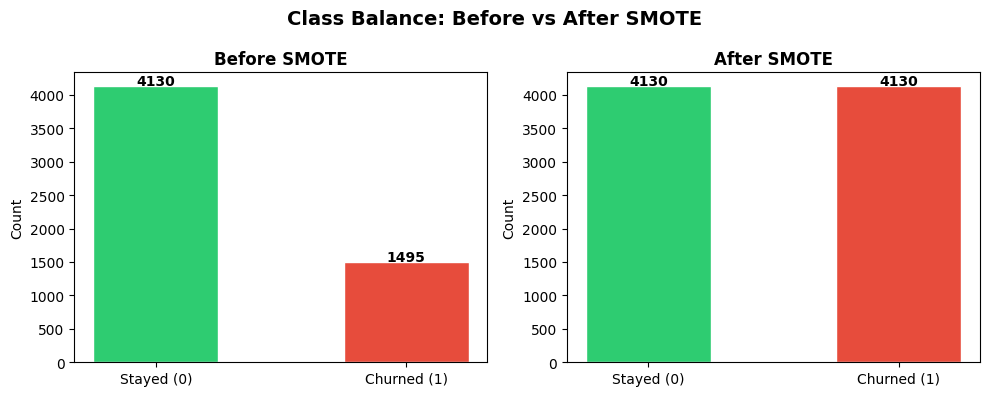

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
axes[0].bar(['Stayed (0)', 'Churned (1)'],
            [sum(y_train == 0), sum(y_train == 1)],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([sum(y_train == 0), sum(y_train == 1)]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# After
axes[1].bar(['Stayed (0)', 'Churned (1)'],
            [sum(y_train_sm == 0), sum(y_train_sm == 1)],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([sum(y_train_sm == 0), sum(y_train_sm == 1)]):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

# Train
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

# Predict
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=" * 45)
print("      LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, lr_prob)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Stayed','Churned']))

      LOGISTIC REGRESSION RESULTS
Accuracy  : 73.63%
ROC-AUC   : 83.34%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1033
     Churned       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [20]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

# Predict
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=" * 45)
print("         RANDOM FOREST RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_prob)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Stayed','Churned']))

         RANDOM FOREST RESULTS
Accuracy  : 77.19%
ROC-AUC   : 81.16%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.84      0.84      1033
     Churned       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.77      0.77      1407



In [21]:
# Install if needed
# !pip install xgboost

from xgboost import XGBClassifier

# Train
xgb = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train_sm, y_train_sm)

# Predict
xgb_pred = xgb.predict(X_test_scaled)
xgb_prob = xgb.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=" * 45)
print("           XGBOOST RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, xgb_prob)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Stayed','Churned']))

           XGBOOST RESULTS
Accuracy  : 77.11%
ROC-AUC   : 81.79%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.83      0.84      1033
     Churned       0.57      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407



              Model  Accuracy (%)  ROC-AUC (%)
Logistic Regression         73.63        83.34
      Random Forest         77.19        81.16
            XGBoost         77.11        81.79


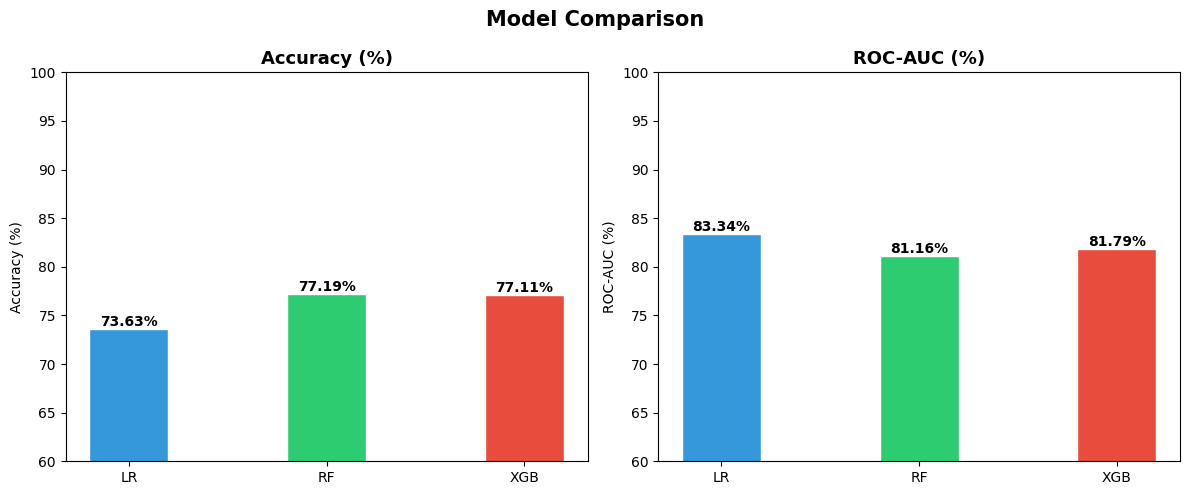

In [22]:
# Summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, lr_pred)*100, 2),
        round(accuracy_score(y_test, rf_pred)*100, 2),
        round(accuracy_score(y_test, xgb_pred)*100, 2)
    ],
    'ROC-AUC (%)': [
        round(roc_auc_score(y_test, lr_prob)*100, 2),
        round(roc_auc_score(y_test, rf_prob)*100, 2),
        round(roc_auc_score(y_test, xgb_prob)*100, 2)
    ]
})

print(results.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
models = ['LR', 'RF', 'XGB']

for ax, metric in zip(axes, ['Accuracy (%)', 'ROC-AUC (%)']):
    bars = ax.bar(models, results[metric], color=colors,
                  edgecolor='white', width=0.4)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylim(60, 100)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val}%', ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

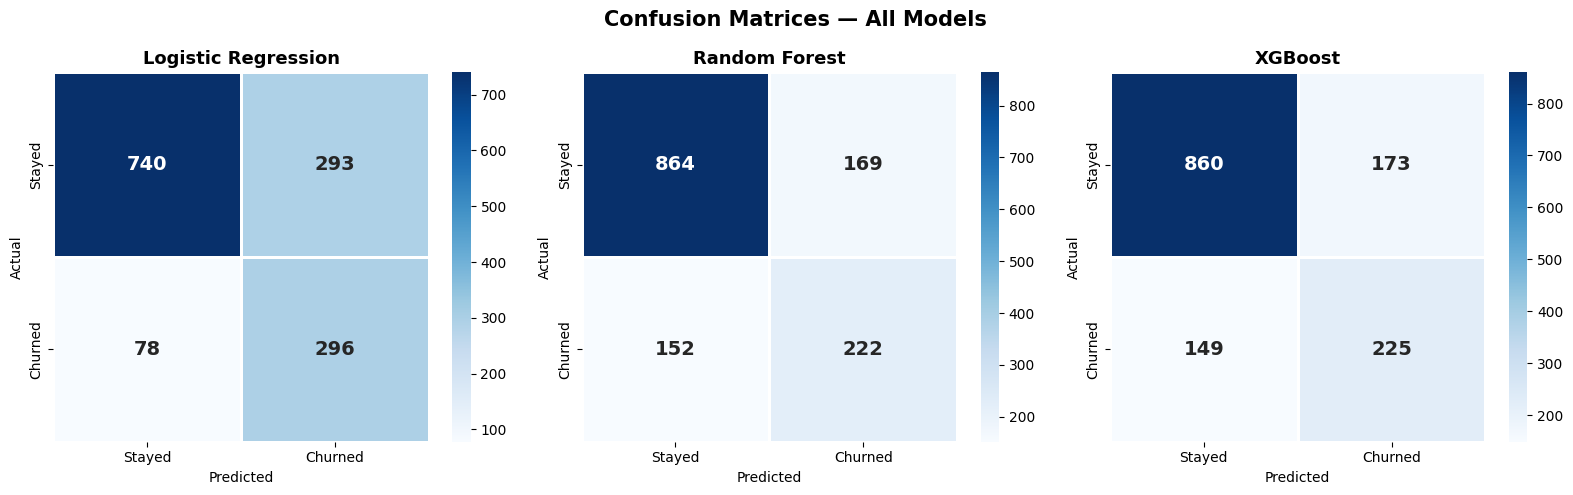

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_info = [
    (lr_pred,  'Logistic Regression', '#3498db'),
    (rf_pred,  'Random Forest',       '#2ecc71'),
    (xgb_pred, 'XGBoost',             '#e74c3c')
]

for ax, (pred, name, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=1, linecolor='white',
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontweight='bold', fontsize=13)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

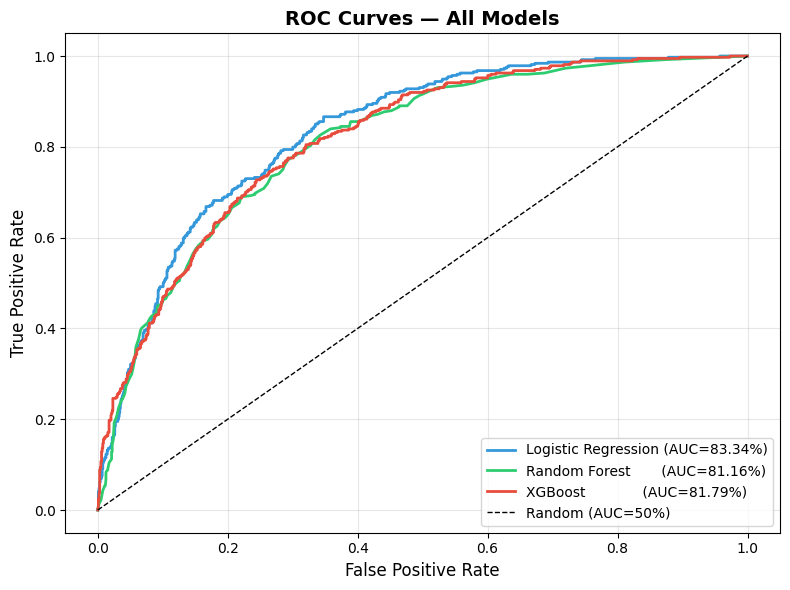

In [24]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for prob, name, color in [
    (lr_prob,  'Logistic Regression (AUC=83.34%)', '#3498db'),
    (rf_prob,  'Random Forest       (AUC=81.16%)', '#2ecc71'),
    (xgb_prob, 'XGBoost             (AUC=81.79%)', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name, linewidth=2, color=color)

# Random baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=50%)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

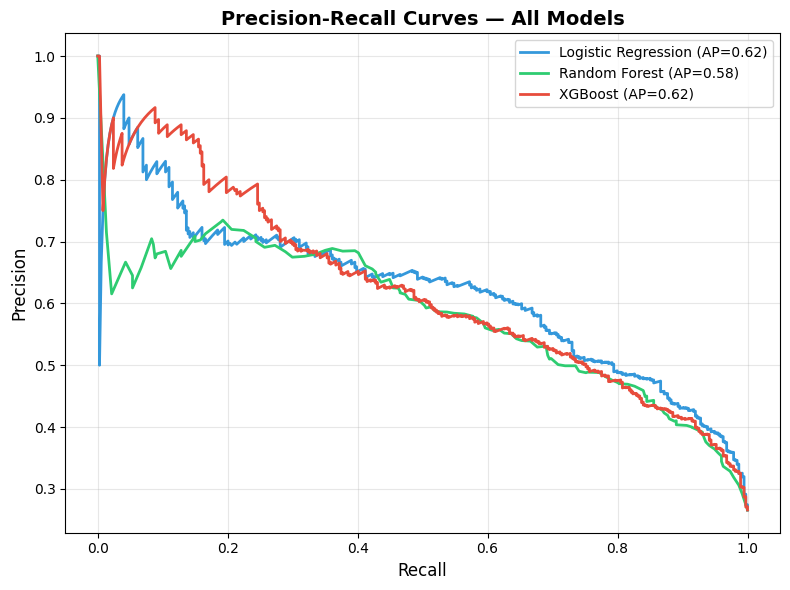

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for prob, name, color in [
    (lr_prob,  'Logistic Regression', '#3498db'),
    (rf_prob,  'Random Forest',       '#2ecc71'),
    (xgb_prob, 'XGBoost',             '#e74c3c')
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec, label=f'{name} (AP={ap:.2f})', linewidth=2, color=color)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

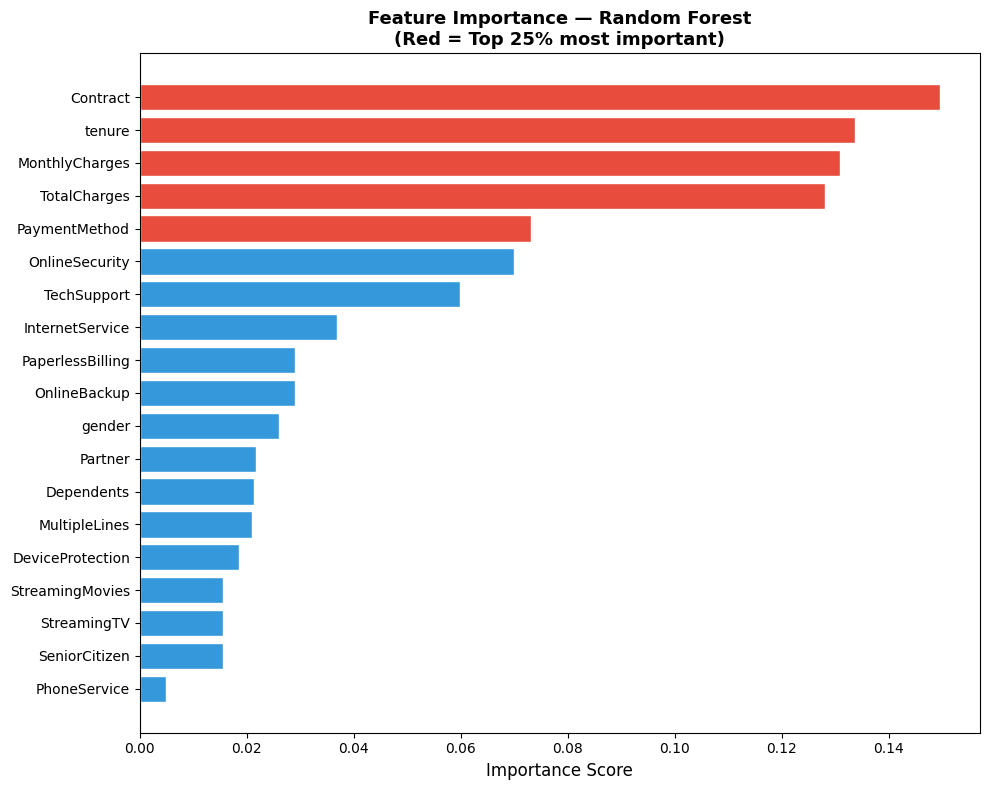

Top 5 most important features:
           Feature  Importance
14        Contract    0.149559
4           tenure    0.133736
17  MonthlyCharges    0.130954
18    TotalCharges    0.128013
16   PaymentMethod    0.073086


In [26]:
# Get feature importances
feature_names = X.columns.tolist()
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > rf_importance['Importance'].quantile(0.75)
          else '#3498db' for x in rf_importance['Importance']]

plt.barh(rf_importance['Feature'], rf_importance['Importance'],
         color=colors, edgecolor='white')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest\n(Red = Top 25% most important)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(rf_importance.sort_values('Importance', ascending=False).head())

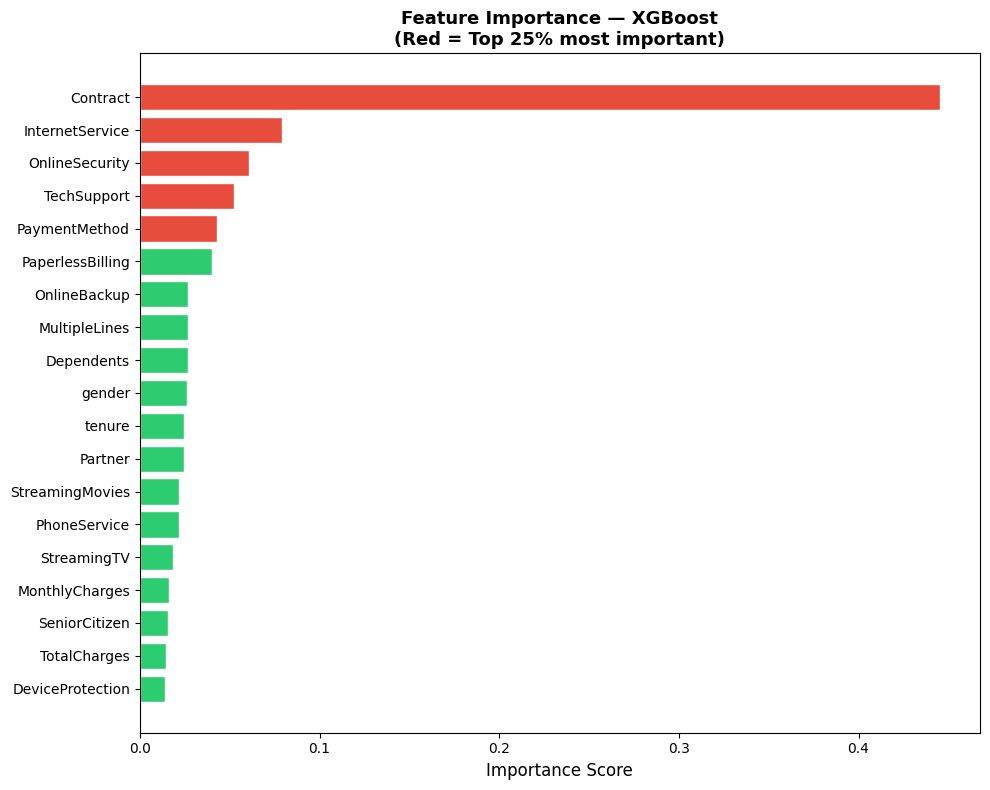

Top 5 most important features:
            Feature  Importance
14         Contract    0.445337
7   InternetService    0.079315
8    OnlineSecurity    0.060995
11      TechSupport    0.052554
16    PaymentMethod    0.043124


In [27]:
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > xgb_importance['Importance'].quantile(0.75)
          else '#2ecc71' for x in xgb_importance['Importance']]

plt.barh(xgb_importance['Feature'], xgb_importance['Importance'],
         color=colors, edgecolor='white')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — XGBoost\n(Red = Top 25% most important)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(xgb_importance.sort_values('Importance', ascending=False).head())

In [28]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=30,              # try 30 random combinations
    scoring='roc_auc',      # optimize for ROC-AUC
    cv=5,                   # 5-fold cross validation
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    verbose=1
)

print("⏳ Tuning XGBoost... (takes 2-3 mins)")
search.fit(X_train_sm, y_train_sm)

print("\n✅ Best Parameters Found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV ROC-AUC: {search.best_score_*100:.2f}%")

⏳ Tuning XGBoost... (takes 2-3 mins)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Parameters Found:
  subsample: 0.9
  n_estimators: 300
  min_child_weight: 1
  max_depth: 6
  learning_rate: 0.1
  colsample_bytree: 0.7

Best CV ROC-AUC: 93.52%


In [29]:
# Best model
best_xgb = search.best_estimator_

# Predict
best_xgb_pred = best_xgb.predict(X_test_scaled)
best_xgb_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("=" * 45)
print("      TUNED XGBOOST RESULTS")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, best_xgb_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, best_xgb_prob)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, best_xgb_pred,
                            target_names=['Stayed', 'Churned']))

# Compare before vs after tuning
print("=" * 45)
print("         BEFORE vs AFTER TUNING")
print("=" * 45)
print(f"XGBoost Before — Accuracy: 77.11%  ROC-AUC: 81.79%")
print(f"XGBoost After  — Accuracy: {accuracy_score(y_test, best_xgb_pred)*100:.2f}%  "
      f"ROC-AUC: {roc_auc_score(y_test, best_xgb_prob)*100:.2f}%")

      TUNED XGBOOST RESULTS
Accuracy : 77.40%
ROC-AUC  : 81.62%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.84      0.85      1033
     Churned       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.78      1407

         BEFORE vs AFTER TUNING
XGBoost Before — Accuracy: 77.11%  ROC-AUC: 81.79%
XGBoost After  — Accuracy: 77.40%  ROC-AUC: 81.62%


              Model  Accuracy (%)  ROC-AUC (%)
Logistic Regression         73.63        83.34
      Random Forest         77.19        81.16
            XGBoost         77.11        81.79
    XGBoost (Tuned)         77.40        81.62


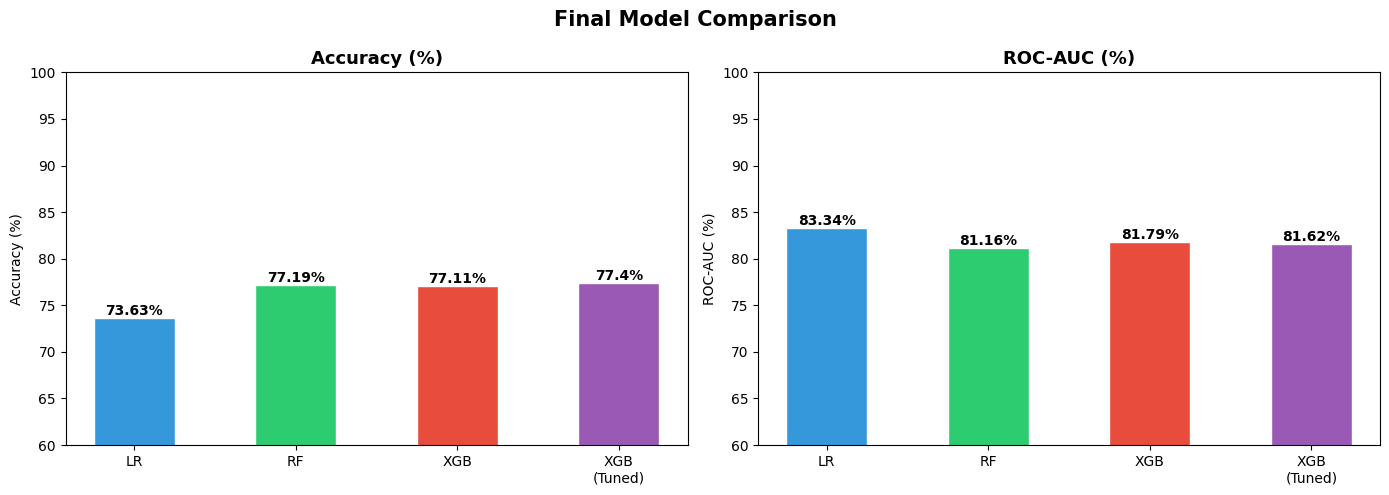

In [30]:
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest',
              'XGBoost', 'XGBoost (Tuned)'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, lr_pred)*100, 2),
        round(accuracy_score(y_test, rf_pred)*100, 2),
        round(accuracy_score(y_test, xgb_pred)*100, 2),
        round(accuracy_score(y_test, best_xgb_pred)*100, 2)
    ],
    'ROC-AUC (%)': [
        round(roc_auc_score(y_test, lr_prob)*100, 2),
        round(roc_auc_score(y_test, rf_prob)*100, 2),
        round(roc_auc_score(y_test, xgb_prob)*100, 2),
        round(roc_auc_score(y_test, best_xgb_prob)*100, 2)
    ]
})

print(final_results.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
model_labels = ['LR', 'RF', 'XGB', 'XGB\n(Tuned)']

for ax, metric in zip(axes, ['Accuracy (%)', 'ROC-AUC (%)']):
    bars = ax.bar(model_labels, final_results[metric],
                  color=colors, edgecolor='white', width=0.5)
    ax.set_ylim(60, 100)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, final_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Final Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

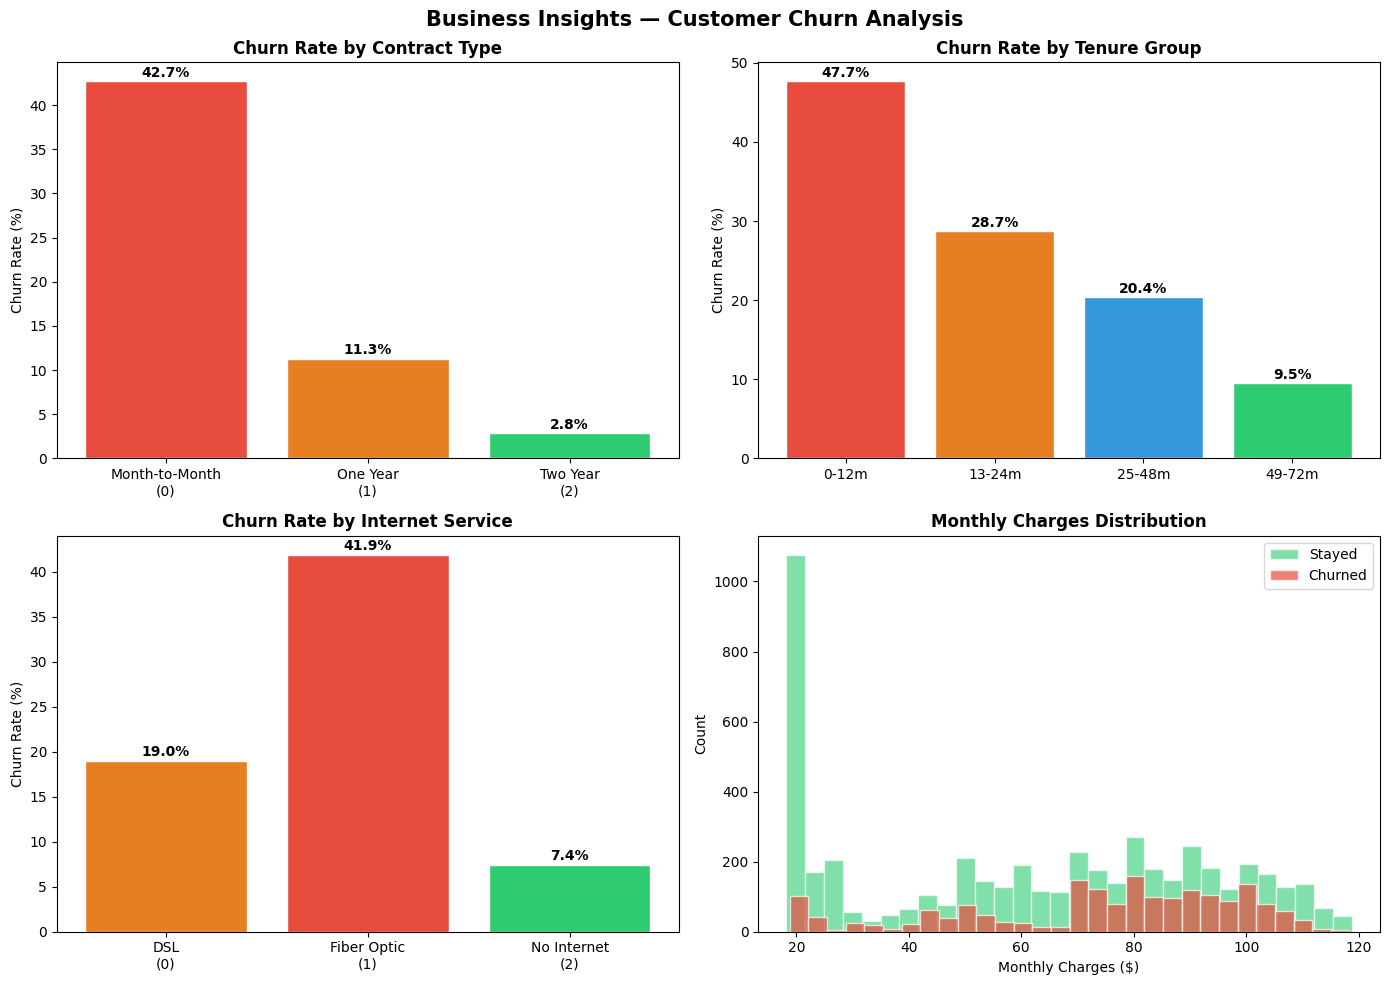

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Churn rate by Contract type ──
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0,0].bar(['Month-to-Month\n(0)', 'One Year\n(1)', 'Two Year\n(2)'],
              contract_churn.values,
              color=['#e74c3c', '#e67e22', '#2ecc71'], edgecolor='white')
axes[0,0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Plot 2: Churn rate by Tenure Group ──
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0,12,24,48,72],
                             labels=['0-12m', '13-24m', '25-48m', '49-72m'])
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
axes[0,1].bar(tenure_churn.index.astype(str), tenure_churn.values,
              color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'], edgecolor='white')
axes[0,1].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[0,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Plot 3: Churn rate by Internet Service ──
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
axes[1,0].bar(['DSL\n(0)', 'Fiber Optic\n(1)', 'No Internet\n(2)'],
              internet_churn.values,
              color=['#e67e22', '#e74c3c', '#2ecc71'], edgecolor='white')
axes[1,0].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    axes[1,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Plot 4: Monthly Charges distribution ──
axes[1,1].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30,
               alpha=0.6, color='#2ecc71', label='Stayed', edgecolor='white')
axes[1,1].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30,
               alpha=0.7, color='#e74c3c', label='Churned', edgecolor='white')
axes[1,1].set_title('Monthly Charges Distribution', fontweight='bold')
axes[1,1].set_xlabel('Monthly Charges ($)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.suptitle('Business Insights — Customer Churn Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Clean up temp column
df.drop(columns=['tenure_group'], inplace=True)

In [32]:
import pickle

# Save Logistic Regression (best ROC-AUC) and scaler
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as churn_model.pkl")
print("✅ Scaler saved as scaler.pkl")

✅ Model saved as churn_model.pkl
✅ Scaler saved as scaler.pkl


In [33]:
# Simulate a new customer and predict churn probability
new_customer = pd.DataFrame([{
    'gender'           : 1,   # Male
    'SeniorCitizen'    : 0,   # Not senior
    'Partner'          : 0,   # No partner
    'Dependents'       : 0,   # No dependents
    'tenure'           : 2,   # Only 2 months — HIGH RISK!
    'PhoneService'     : 1,   # Yes
    'MultipleLines'    : 0,   # No
    'InternetService'  : 1,   # Fiber Optic
    'OnlineSecurity'   : 0,   # No
    'OnlineBackup'     : 0,   # No
    'DeviceProtection' : 0,   # No
    'TechSupport'      : 0,   # No
    'StreamingTV'      : 1,   # Yes
    'StreamingMovies'  : 1,   # Yes
    'Contract'         : 0,   # Month-to-month — HIGH RISK!
    'PaperlessBilling' : 1,   # Yes
    'PaymentMethod'    : 2,   # Electronic check
    'MonthlyCharges'   : 85.5,# High charges — HIGH RISK!
    'TotalCharges'     : 171.0 # Low total (short tenure)
}])

# Scale and predict
new_scaled = scaler.transform(new_customer)
prediction = lr.predict(new_scaled)[0]
probability = lr.predict_proba(new_scaled)[0][1]

print("=" * 40)
print("      NEW CUSTOMER PREDICTION")
print("=" * 40)
print(f"Churn Prediction : {'⚠️  WILL CHURN' if prediction == 1 else '✅ WILL STAY'}")
print(f"Churn Probability: {probability*100:.1f}%")
print(f"\nRisk Level: {'🔴 HIGH' if probability > 0.7 else '🟡 MEDIUM' if probability > 0.4 else '🟢 LOW'}")

      NEW CUSTOMER PREDICTION
Churn Prediction : ⚠️  WILL CHURN
Churn Probability: 89.1%

Risk Level: 🔴 HIGH
